# Inspect V-JEPA 2.1 Latents


This notebook loads `skate_latents.npy` / `skate_latents.metadata.json`, summarizes the tensor, and visualizes the latent grid in a few useful ways.


It assumes the extracted tensor has shape `[batch, time, height, width, embed_dim]`, which for your run is `[1, 8, 16, 16, 1024]`.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
LATENT_NPY = ROOT / "skate_latents.npy"
LATENT_PT = ROOT / "skate_latents.pt"
METADATA_PATH = ROOT / "skate_latents.metadata.json"

def load_latents() -> tuple[np.ndarray, dict]:
    if LATENT_NPY.exists():
        latents = np.load(LATENT_NPY)
    elif LATENT_PT.exists():
        latents = torch.load(LATENT_PT, map_location="cpu").numpy()
    else:
        raise FileNotFoundError("Could not find `skate_latents.npy` or `skate_latents.pt` in the current directory.")

    if not METADATA_PATH.exists():
        raise FileNotFoundError("Could not find `skate_latents.metadata.json` in the current directory.")


    metadata = json.loads(METADATA_PATH.read_text())
    return latents, metadata

def flatten_latents(latents: np.ndarray) -> np.ndarray:
    return latents.reshape(-1, latents.shape[-1])

def pca_project(features: np.ndarray, n_components: int = 3) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    centered = features - features.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ vt[:n_components].T
    explained = (s[:n_components] ** 2) / np.maximum((s ** 2).sum(), 1e-12)
    return coords, vt[:n_components], explained

# lets create a function to get the umap projection of the features as well, we can use the umap-learn library for this
def umap_project(features: np.ndarray, n_components: int = 3) -> np.ndarray:
    import umap
    reducer = umap.UMAP(n_components=n_components)
    return reducer.fit_transform(features)

def minmax_scale(values: np.ndarray) -> np.ndarray:
    mins = values.min(axis=0, keepdims=True)
    maxs = values.max(axis=0, keepdims=True)
    return (values - mins) / np.maximum(maxs - mins, 1e-12)

In [2]:
import cv2
from IPython.display import Video, display

latents, metadata = load_latents()
_, time_steps, grid_h, grid_w, _ = latents.shape

features = flatten_latents(latents)
coords, _, explained = pca_project(features, n_components=3)
rgb_video = minmax_scale(coords).reshape(time_steps, grid_h, grid_w, 3)

In [3]:
umap_projection = umap_project(features, n_components=3)

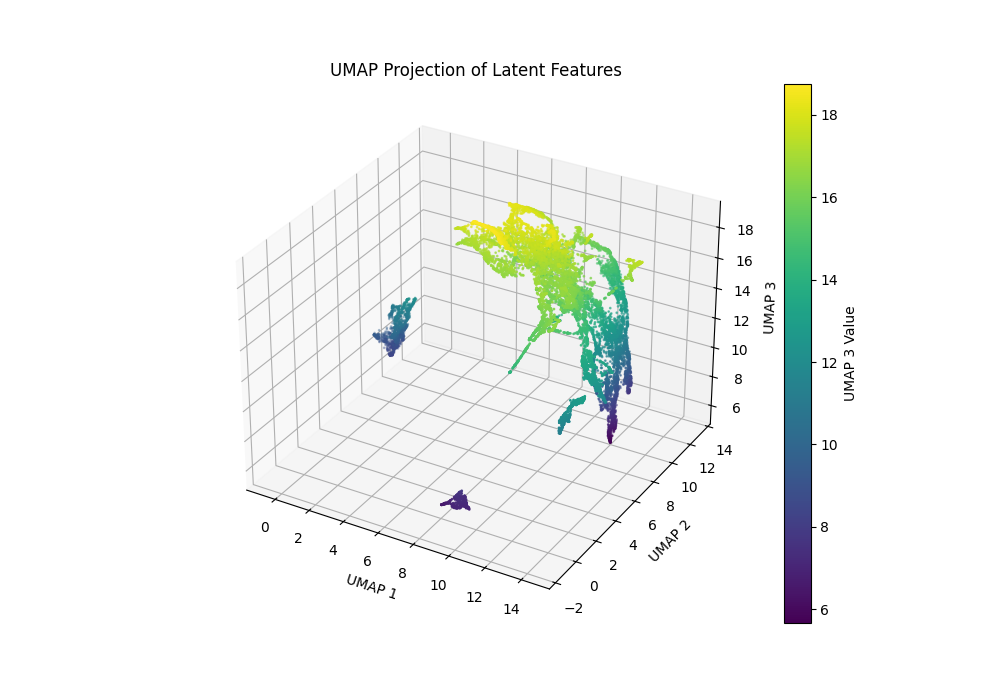

In [13]:
# plot the coords of all the features in the first 3 UMAP dimensions in a 3d scatter plot, where the color of each point is determined by the value of the 3rd UMAP dimension
%matplotlib widget
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(umap_projection[:, 0], umap_projection[:, 1], umap_projection[:, 2], c=umap_projection[:, 2], cmap='viridis', s=1)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.set_title('UMAP Projection of Latent Features')
plt.colorbar(scatter, label='UMAP 3 Value')
plt.show()

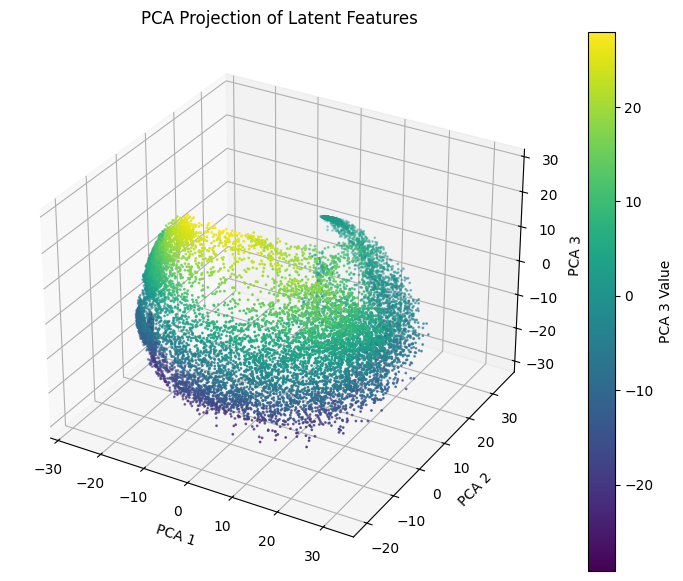

In [ ]:
# plot the coords of all the features in the first 3 PCA dimensions in a 3d scatter plot, where the color of each point is determined by the value of the 3rd PCA dimension
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=coords[:, 2], cmap='viridis', s=1)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('PCA Projection of Latent Features')
plt.colorbar(scatter, label='PCA 3 Value')
plt.show()


In [ ]:


target_resolution = int(metadata.get("crop_size", 384))
video_fps = float(metadata.get("video_metadata", {}).get("fps", 6.0))
pca_output_filename = ROOT / "latent_space_pca_smooth_384.mp4"
side_by_side_filename = ROOT / "latent_space_side_by_side_384.mp4"

frame_indices = np.asarray(metadata.get("frame_indices", list(range(time_steps))), dtype=int)
frame_groups = np.array_split(frame_indices, time_steps)
aligned_frame_indices = [int(group[len(group) // 2]) for group in frame_groups]
duplication_factor = max(1, len(frame_indices) // max(1, time_steps))

source_video_path = Path(metadata["video_path"] if "video_path" in metadata else "")
if not source_video_path.exists():
    raise FileNotFoundError(f"Could not find source video at {source_video_path}")

def center_crop_to_square(image_rgb: np.ndarray) -> np.ndarray:
    height, width = image_rgb.shape[:2]
    crop_size = min(height, width)
    top = (height - crop_size) // 2
    left = (width - crop_size) // 2
    return image_rgb[top:top + crop_size, left:left + crop_size]

def make_labeled_panel(image_rgb: np.ndarray, title: str, subtitle: str, crop_to_square: bool = False) -> np.ndarray:
    if crop_to_square:
        image_rgb = center_crop_to_square(image_rgb)
    panel = cv2.resize(image_rgb, (target_resolution, target_resolution), interpolation=cv2.INTER_CUBIC)
    panel_bgr = cv2.cvtColor(panel, cv2.COLOR_RGB2BGR)
    panel_bgr = cv2.copyMakeBorder(panel_bgr, 48, 12, 12, 12, cv2.BORDER_CONSTANT, value=(18, 18, 18))
    cv2.putText(panel_bgr, title, (16, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(panel_bgr, subtitle, (16, panel_bgr.shape[0] - 14), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (210, 210, 210), 1, cv2.LINE_AA)
    return panel_bgr

cap = cv2.VideoCapture(str(source_video_path))
if not cap.isOpened():
    raise RuntimeError(f"Could not open source video {source_video_path}")

single_frame_size = (target_resolution, target_resolution)
panel_width = target_resolution + 24
panel_height = target_resolution + 60
gap = 16
side_by_side_size = (panel_width * 2 + gap * 3, panel_height + 24)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
pca_writer = cv2.VideoWriter(str(pca_output_filename), fourcc, video_fps, single_frame_size)
comparison_writer = cv2.VideoWriter(str(side_by_side_filename), fourcc, video_fps, side_by_side_size)

if not pca_writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {pca_output_filename}")
if not comparison_writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {side_by_side_filename}")

for time_index, (pca_frame, frame_number) in enumerate(zip(rgb_video, aligned_frame_indices)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ok, source_bgr = cap.read()
    if not ok:
        source_bgr = np.zeros((target_resolution, target_resolution, 3), dtype=np.uint8)
    source_rgb = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2RGB)

    pca_rgb = (np.clip(pca_frame, 0.0, 1.0) * 255).astype(np.uint8)
    pca_smooth_rgb = cv2.resize(pca_rgb, single_frame_size, interpolation=cv2.INTER_CUBIC)
    pca_bgr = cv2.cvtColor(pca_smooth_rgb, cv2.COLOR_RGB2BGR)

    source_panel = make_labeled_panel(source_rgb, "Input frame", f"frame={frame_number}", crop_to_square=True)
    pca_panel = make_labeled_panel(pca_rgb, "Latent PCA", f"t={time_index}")

    comparison_frame = np.full((side_by_side_size[1], side_by_side_size[0], 3), 12, dtype=np.uint8)
    left_start = gap
    right_start = gap * 2 + panel_width
    comparison_frame[12:12 + panel_height, left_start:left_start + panel_width] = source_panel
    comparison_frame[12:12 + panel_height, right_start:right_start + panel_width] = pca_panel
    cv2.putText(comparison_frame, "Original vs. latent-space PCA", (18, side_by_side_size[1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

    for _ in range(duplication_factor):
        pca_writer.write(pca_bgr)
        comparison_writer.write(comparison_frame)

cap.release()
pca_writer.release()
comparison_writer.release()

print(f"Saved smooth PCA video to: {pca_output_filename}")
print(f"Saved side-by-side video to: {side_by_side_filename}")
print(f"PCA resolution: {single_frame_size[0]}x{single_frame_size[1]}")
print(f"Side-by-side resolution: {side_by_side_size[0]}x{side_by_side_size[1]}")
print("Input frame panel uses a center crop before resizing, so it matches the square model crop without stretching.")
print(f"Each latent timestep is duplicated {duplication_factor}x to preserve the original clip timing.")
print("Explained variance:", ", ".join(f"PC{i + 1}={value:.4f}" for i, value in enumerate(explained)))

display(Video(str(side_by_side_filename), embed=True))

Saved smooth PCA video to: /Users/pishty/ws/vjepa2.1/latent_space_pca_smooth_384.mp4
Saved side-by-side video to: /Users/pishty/ws/vjepa2.1/latent_space_side_by_side_384.mp4
PCA resolution: 384x384
Side-by-side resolution: 864x468
Input frame panel uses a center crop before resizing, so it matches the square model crop without stretching.
Each latent timestep is duplicated 2x to preserve the original clip timing.
Explained variance: PC1=0.3467, PC2=0.2515, PC3=0.1181


## PCA pattern plots

These plots turn the PCA coordinates into time-series views so you can spot trends, changes, and repeating structure across latent timesteps.

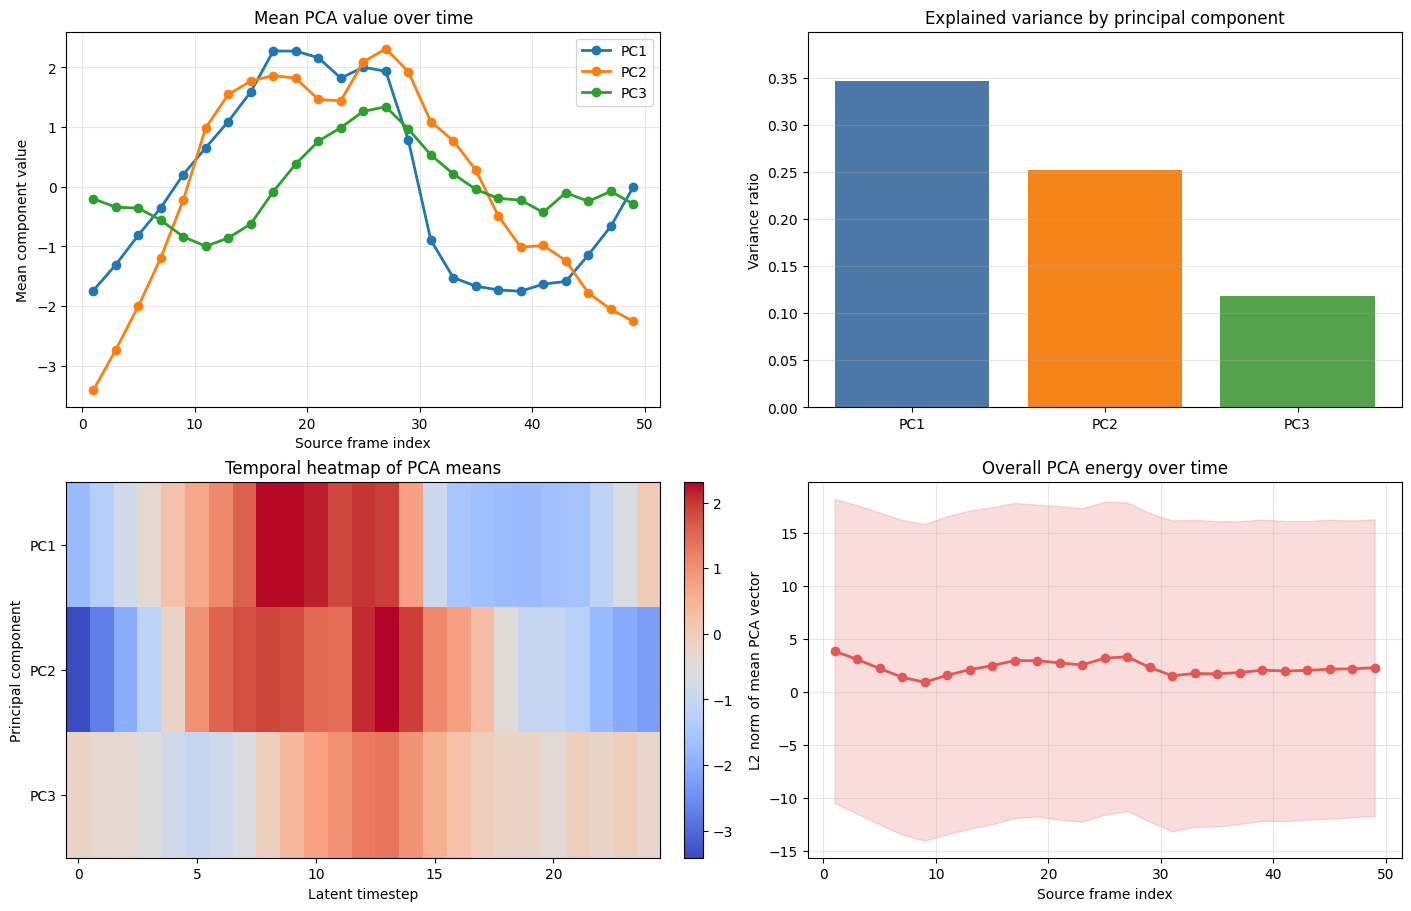

Per-timestep PCA means:
t=00: PC1=-1.7393, PC2=-3.4117, PC3=-0.2014
t=01: PC1=-1.3077, PC2=-2.7337, PC3=-0.3424
t=02: PC1=-0.8123, PC2=-2.0051, PC3=-0.3580
t=03: PC1=-0.3530, PC2=-1.1936, PC3=-0.5591
t=04: PC1=+0.2054, PC2=-0.2207, PC3=-0.8376
t=05: PC1=+0.6556, PC2=+0.9887, PC3=-0.9976
t=06: PC1=+1.0934, PC2=+1.5478, PC3=-0.8593
t=07: PC1=+1.5905, PC2=+1.7705, PC3=-0.6229
t=08: PC1=+2.2766, PC2=+1.8645, PC3=-0.0809
t=09: PC1=+2.2733, PC2=+1.8185, PC3=+0.3827
t=10: PC1=+2.1637, PC2=+1.4638, PC3=+0.7634
t=11: PC1=+1.8224, PC2=+1.4404, PC3=+0.9909
t=12: PC1=+2.0023, PC2=+2.0945, PC3=+1.2635
t=13: PC1=+1.9367, PC2=+2.3135, PC3=+1.3416
t=14: PC1=+0.7841, PC2=+1.9298, PC3=+0.9687
t=15: PC1=-0.8923, PC2=+1.0918, PC3=+0.5346
t=16: PC1=-1.5230, PC2=+0.7720, PC3=+0.2148
t=17: PC1=-1.6653, PC2=+0.2810, PC3=-0.0434
t=18: PC1=-1.7295, PC2=-0.4886, PC3=-0.1938
t=19: PC1=-1.7510, PC2=-1.0137, PC3=-0.2248
t=20: PC1=-1.6314, PC2=-0.9823, PC3=-0.4292
t=21: PC1=-1.5875, PC2=-1.2380, PC3=-0.0993
t=22: PC

In [3]:
if "coords" not in globals() or "explained" not in globals():
    latents, metadata = load_latents()
    _, time_steps, grid_h, grid_w, _ = latents.shape
    features = flatten_latents(latents)
    coords, _, explained = pca_project(features, n_components=3)
else:
    _, time_steps, grid_h, grid_w, _ = latents.shape

coords_video = coords.reshape(time_steps, grid_h, grid_w, 3)
mean_pc_per_timestep = coords_video.mean(axis=(1, 2))
std_pc_per_timestep = coords_video.std(axis=(1, 2))
pc_energy_per_timestep = np.linalg.norm(mean_pc_per_timestep, axis=1)

x_values = np.arange(time_steps)
if "aligned_frame_indices" in globals() and len(aligned_frame_indices) == time_steps:
    x_values = np.asarray(aligned_frame_indices)
    x_label = "Source frame index"
else:
    x_label = "Latent timestep"

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

for component_index in range(3):
    axes[0, 0].plot(
        x_values,
        mean_pc_per_timestep[:, component_index],
        marker="o",
        linewidth=2,
        label=f"PC{component_index + 1}",
    )
axes[0, 0].set_title("Mean PCA value over time")
axes[0, 0].set_xlabel(x_label)
axes[0, 0].set_ylabel("Mean component value")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].bar(
    ["PC1", "PC2", "PC3"],
    explained,
    color=["#4C78A8", "#F58518", "#54A24B"],
)
axes[0, 1].set_title("Explained variance by principal component")
axes[0, 1].set_ylabel("Variance ratio")
axes[0, 1].set_ylim(0, max(0.05, explained.max() * 1.15))
axes[0, 1].grid(axis="y", alpha=0.3)

heatmap = axes[1, 0].imshow(
    mean_pc_per_timestep.T,
    aspect="auto",
    cmap="coolwarm",
    interpolation="nearest",
)
axes[1, 0].set_title("Temporal heatmap of PCA means")
axes[1, 0].set_xlabel("Latent timestep")
axes[1, 0].set_ylabel("Principal component")
axes[1, 0].set_yticks([0, 1, 2], labels=["PC1", "PC2", "PC3"])
fig.colorbar(heatmap, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].plot(x_values, pc_energy_per_timestep, marker="o", color="#E45756", linewidth=2)
axes[1, 1].fill_between(
    x_values,
    pc_energy_per_timestep - std_pc_per_timestep.mean(axis=1),
    pc_energy_per_timestep + std_pc_per_timestep.mean(axis=1),
    alpha=0.2,
    color="#E45756",
)
axes[1, 1].set_title("Overall PCA energy over time")
axes[1, 1].set_xlabel(x_label)
axes[1, 1].set_ylabel("L2 norm of mean PCA vector")
axes[1, 1].grid(alpha=0.3)

plt.show()

print("Per-timestep PCA means:")
for timestep_index, values in enumerate(mean_pc_per_timestep):
    print(
        f"t={timestep_index:02d}: "
        + ", ".join(f"PC{i + 1}={value:+.4f}" for i, value in enumerate(values))
    )

## 3D PCA trajectory

This view plots each latent timestep in `PC1`/`PC2`/`PC3` space so you can see the motion of the clip as a trajectory through latent space.

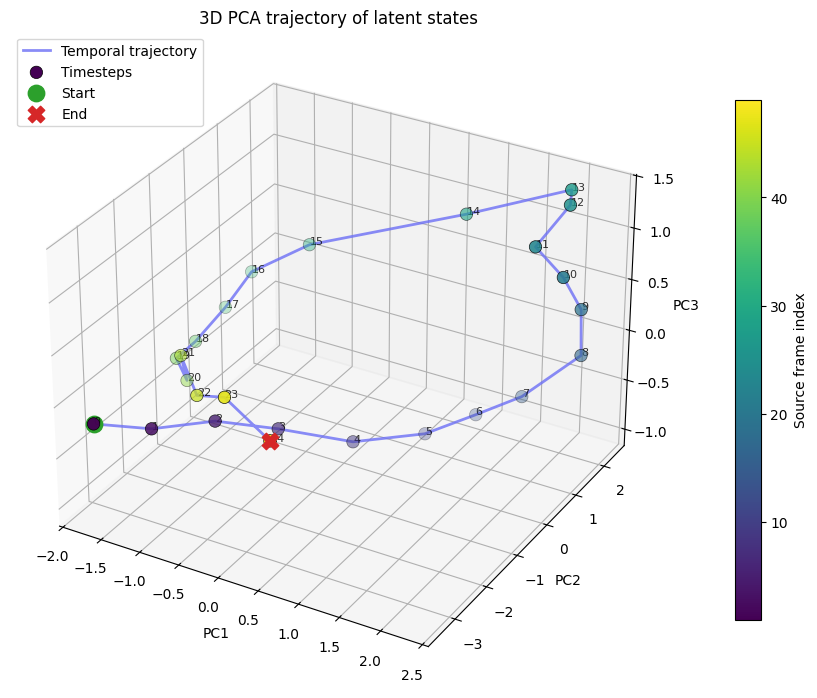

3D trajectory points (mean PCA per timestep):
t=00: PC1=-1.7393, PC2=-3.4117, PC3=-0.2014
t=01: PC1=-1.3077, PC2=-2.7337, PC3=-0.3424
t=02: PC1=-0.8123, PC2=-2.0051, PC3=-0.3580
t=03: PC1=-0.3530, PC2=-1.1936, PC3=-0.5591
t=04: PC1=+0.2054, PC2=-0.2207, PC3=-0.8376
t=05: PC1=+0.6556, PC2=+0.9887, PC3=-0.9976
t=06: PC1=+1.0934, PC2=+1.5478, PC3=-0.8593
t=07: PC1=+1.5905, PC2=+1.7705, PC3=-0.6229
t=08: PC1=+2.2766, PC2=+1.8645, PC3=-0.0809
t=09: PC1=+2.2733, PC2=+1.8185, PC3=+0.3827
t=10: PC1=+2.1637, PC2=+1.4638, PC3=+0.7634
t=11: PC1=+1.8224, PC2=+1.4404, PC3=+0.9909
t=12: PC1=+2.0023, PC2=+2.0945, PC3=+1.2635
t=13: PC1=+1.9367, PC2=+2.3135, PC3=+1.3416
t=14: PC1=+0.7841, PC2=+1.9298, PC3=+0.9687
t=15: PC1=-0.8923, PC2=+1.0918, PC3=+0.5346
t=16: PC1=-1.5230, PC2=+0.7720, PC3=+0.2148
t=17: PC1=-1.6653, PC2=+0.2810, PC3=-0.0434
t=18: PC1=-1.7295, PC2=-0.4886, PC3=-0.1938
t=19: PC1=-1.7510, PC2=-1.0137, PC3=-0.2248
t=20: PC1=-1.6314, PC2=-0.9823, PC3=-0.4292
t=21: PC1=-1.5875, PC2=-1.2380

In [4]:
if "coords" not in globals():
    latents, metadata = load_latents()
    _, time_steps, grid_h, grid_w, _ = latents.shape
    features = flatten_latents(latents)
    coords, _, explained = pca_project(features, n_components=3)
else:
    _, time_steps, grid_h, grid_w, _ = latents.shape

coords_video = coords.reshape(time_steps, grid_h, grid_w, 3)
mean_pc_per_timestep = coords_video.mean(axis=(1, 2))

time_axis = np.arange(time_steps)
if "aligned_frame_indices" in globals() and len(aligned_frame_indices) == time_steps:
    time_axis = np.asarray(aligned_frame_indices)
    time_label = "Source frame index"
else:
    time_label = "Latent timestep"

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

trajectory = mean_pc_per_timestep
line = ax.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    trajectory[:, 2],
    color="#6C6FF5",
    linewidth=2,
    alpha=0.8,
    label="Temporal trajectory",
)[0]

scatter = ax.scatter(
    trajectory[:, 0],
    trajectory[:, 1],
    trajectory[:, 2],
    c=time_axis,
    cmap="viridis",
    s=80,
    edgecolor="black",
    linewidth=0.5,
    label="Timesteps",
)

for timestep_index, point in enumerate(trajectory):
    ax.text(
        point[0],
        point[1],
        point[2],
        str(timestep_index),
        fontsize=8,
        alpha=0.8,
    )

ax.scatter(
    trajectory[0, 0],
    trajectory[0, 1],
    trajectory[0, 2],
    color="#2CA02C",
    s=140,
    marker="o",
    label="Start",
)
ax.scatter(
    trajectory[-1, 0],
    trajectory[-1, 1],
    trajectory[-1, 2],
    color="#D62728",
    s=140,
    marker="X",
    label="End",
)

ax.set_title("3D PCA trajectory of latent states")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

colorbar = fig.colorbar(scatter, ax=ax, pad=0.08, shrink=0.75)
colorbar.set_label(time_label)

plt.show()

print("3D trajectory points (mean PCA per timestep):")
for timestep_index, point in enumerate(trajectory):
    print(
        f"t={timestep_index:02d}: PC1={point[0]:+.4f}, PC2={point[1]:+.4f}, PC3={point[2]:+.4f}"
    )